## **Setup**

In [1]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

Repo already exists — pulling latest changes
fatal: unable to access 'https://github.com/Lv1g1/RecSys-Challenge-2025.git/': Could not resolve host: github.com


In [ ]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

In [3]:
if IS_COLAB or IS_KAGGLE:
    !pip install optuna

import optuna

In [4]:
import importlib
import numpy as np

from Challenge import paths
importlib.reload(paths)

from Challenge.hyper_tuning import ModelOptimizer

Running on local — storage at: /home/luigi/RecSys
Running on local — storage at: /home/luigi/RecSys


/home/luigi/RecSys/Challenge/hyper_tuning.py:75: ExperimentalWarning: WilcoxonPruner is experimental (supported from v3.6.0). The interface can change in the future.
  def create_study(self, study_name, direction="maximize", load_if_exists=True, pruner=optuna.pruners.WilcoxonPruner()):
/home/luigi/RecSys/Challenge/hyper_tuning.py:107: ExperimentalWarning: WilcoxonPruner is experimental (supported from v3.6.0). The interface can change in the future.
  def create_and_optimize_study(self, study_name, objective_function, n_trials=50, direction="maximize", load_if_exists=True, pruner=optuna.pruners.WilcoxonPruner()):


## **Load Data**

In [ ]:
URM_train, URM_val = paths.load_holdout_split()

## **Analisys**

In [6]:
import scipy.sparse as sps

URM_train = sps.csr_matrix(URM_train)
URM_val = sps.csr_matrix(URM_val)

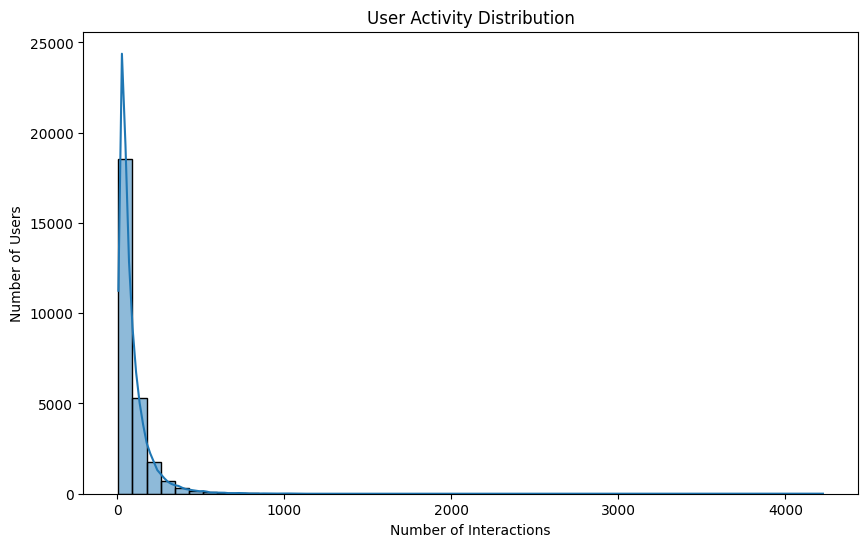

In [7]:
# Plot user activity distribution
import matplotlib.pyplot as plt
import seaborn as sns

user_activity = np.ediff1d(URM_train.indptr)
plt.figure(figsize=(10, 6))
sns.histplot(user_activity, bins=50, kde=True)
plt.title("User Activity Distribution")
plt.xlabel("Number of Interactions")
plt.ylabel("Number of Users")
plt.show()

## **Load Models**

### **Train Fast Models**

In [8]:
from Recommenders.NonPersonalizedRecommender import TopPop
from Recommenders.KNN.UserKNNCFRecommender import UserKNNCFRecommender
from Recommenders.KNN.ItemKNNCFRecommender import ItemKNNCFRecommender
from Recommenders.GraphBased.P3alphaRecommender import P3alphaRecommender
from Recommenders.GraphBased.RP3betaRecommender import RP3betaRecommender
from Recommenders.EASE_R.EASE_R_Recommender import EASE_R_Recommender
from Recommenders.SLIM.SLIMElasticNetRecommender import MultiThreadSLIM_SLIMElasticNetRecommender

from Recommenders.SLIM.Cython.SLIM_BPR_Cython import SLIM_BPR_Cython
from Recommenders.MatrixFactorization.IALSRecommender import IALSRecommender
from Recommenders.MatrixFactorization.PureSVDRecommender import PureSVDRecommender
from Recommenders.MatrixFactorization.NMFRecommender import NMFRecommender
from Recommenders.Neural.MultVAERecommender import MultVAERecommender

models = {}

TRAIN = False
model_folder = os.path.join(paths.MODEL_DIR, "xg_boost")

Tensorflow is not available


In [9]:
import json

def get_best_params(json_path: str) -> dict:
    with open(json_path, "r") as f:
        data = json.load(f)
        
        best_study = None
        for _, values in data.items():
            if best_study is None:
                best_study = values
                continue

            if values["best_score"] > best_study["best_score"]:
                best_study = values
                
    return best_study["best_params"]

In [10]:
if TRAIN:
    # TopPop
    model = TopPop(URM_train)
    model.fit()
    models["TopPop"] = model

    # KNN
    KNN_similarities = ["cosine", "jaccard", "asymmetric", "tversky", "dice"]
    for sim in KNN_similarities:
        path = os.path.join(LOCAL_REPO_PATH, f"performance_logs/UserKNN_{sim}.json")
        best_params = get_best_params(path)
                
        user_model = UserKNNCFRecommender(URM_train)
        user_model.fit(**best_params)
        models[f"UserKNNCF_{sim}"] = user_model
        
        path = os.path.join(LOCAL_REPO_PATH, f"performance_logs/ItemKNN_{sim}.json")
        best_params = get_best_params(path)

        item_model = ItemKNNCFRecommender(URM_train)
        item_model.fit(**best_params)
        models[f"ItemKNNCF_{sim}"] = item_model

    # P3alpha
    path = os.path.join(LOCAL_REPO_PATH, f"performance_logs/P3alpha.json")
    best_params = get_best_params(path)
    p3alpha_model = P3alphaRecommender(URM_train)
    p3alpha_model.fit(**best_params)
    models["P3alpha"] = p3alpha_model

    # RP3beta
    path = os.path.join(LOCAL_REPO_PATH, f"performance_logs/RP3beta.json")
    best_params = get_best_params(path)
    rp3beta_model = RP3betaRecommender(URM_train)
    rp3beta_model.fit(**best_params)
    models["RP3beta"] = rp3beta_model

    # EASE-R
    path = os.path.join(LOCAL_REPO_PATH, f"performance_logs/EASE_R.json")
    best_params = get_best_params(path)
    ease_r_model = EASE_R_Recommender(URM_train)
    ease_r_model.fit(**best_params)
    models["EASE_R"] = ease_r_model

    # SLIM ElasticNet
    path = os.path.join(LOCAL_REPO_PATH, f"performance_logs/SLIMElasticNet.json")
    best_params = get_best_params(path)
    slim_en_model = MultiThreadSLIM_SLIMElasticNetRecommender(URM_train)
    slim_en_model.fit(**best_params, workers=8)
    models["SLIMElasticNet"] = slim_en_model

    # Save models
    for model_name, model in models.items():
        model.save_model(model_folder, model_name)

else:
    models["TopPop"] = TopPop(URM_train)
    models["TopPop"].load_model(model_folder, "TopPop")
    for sim in ["cosine", "jaccard", "asymmetric", "tversky", "dice"]:
        models[f"UserKNNCF_{sim}"] = UserKNNCFRecommender(URM_train)
        models[f"UserKNNCF_{sim}"].load_model(model_folder, f"UserKNNCF_{sim}")
        models[f"ItemKNNCF_{sim}"] = ItemKNNCFRecommender(URM_train)
        models[f"ItemKNNCF_{sim}"].load_model(model_folder, f"ItemKNNCF_{sim}")
    models["RP3beta"] = RP3betaRecommender(URM_train)
    models["RP3beta"].load_model(model_folder, "RP3beta")
    models["EASE_R"] = EASE_R_Recommender(URM_train)
    models["EASE_R"].load_model(model_folder, "EASE_R")
    models["SLIMElasticNet"] = MultiThreadSLIM_SLIMElasticNetRecommender(URM_train)
    models["SLIMElasticNet"].load_model(model_folder, "SLIMElasticNet")

TopPopRecommender: Loading model from file '/home/luigi/RecSys/models/xg_boostTopPop'
TopPopRecommender: Loading complete
UserKNNCFRecommender: Loading model from file '/home/luigi/RecSys/models/xg_boostUserKNNCF_cosine'
UserKNNCFRecommender: Loading complete
ItemKNNCFRecommender: Loading model from file '/home/luigi/RecSys/models/xg_boostItemKNNCF_cosine'
ItemKNNCFRecommender: Loading complete
UserKNNCFRecommender: Loading model from file '/home/luigi/RecSys/models/xg_boostUserKNNCF_jaccard'
UserKNNCFRecommender: Loading complete
ItemKNNCFRecommender: Loading model from file '/home/luigi/RecSys/models/xg_boostItemKNNCF_jaccard'
ItemKNNCFRecommender: Loading complete
UserKNNCFRecommender: Loading model from file '/home/luigi/RecSys/models/xg_boostUserKNNCF_asymmetric'
UserKNNCFRecommender: Loading complete
ItemKNNCFRecommender: Loading model from file '/home/luigi/RecSys/models/xg_boostItemKNNCF_asymmetric'
ItemKNNCFRecommender: Loading complete
UserKNNCFRecommender: Loading model from

In [11]:
print(f"{len(models)} models")
models.keys()

14 models


dict_keys(['TopPop', 'UserKNNCF_cosine', 'ItemKNNCF_cosine', 'UserKNNCF_jaccard', 'ItemKNNCF_jaccard', 'UserKNNCF_asymmetric', 'ItemKNNCF_asymmetric', 'UserKNNCF_tversky', 'ItemKNNCF_tversky', 'UserKNNCF_dice', 'ItemKNNCF_dice', 'RP3beta', 'EASE_R', 'SLIMElasticNet'])

In [12]:
from Evaluation.Evaluator import EvaluatorHoldout

evaluator = EvaluatorHoldout(URM_val, [20])

EvaluatorHoldout: Ignoring 25 ( 0.1%) Users that have less than 1 test interactions


In [14]:
for model_name, model in models.items():
    print(f"Evaluating {model_name}...")
    score = evaluator.evaluateRecommender(model)[0].loc[20, 'RECALL']
    print(f"  Score: {score}")

Evaluating TopPop...
EvaluatorHoldout: Processed 27070 (100.0%) in 4.58 sec. Users per second: 5912
  Score: 0.10673706431059295
Evaluating UserKNNCF_cosine...
EvaluatorHoldout: Processed 27070 (100.0%) in 8.86 sec. Users per second: 3056
  Score: 0.2189980449173681
Evaluating ItemKNNCF_cosine...
EvaluatorHoldout: Processed 27070 (100.0%) in 6.93 sec. Users per second: 3909
  Score: 0.21726350062159716
Evaluating UserKNNCF_jaccard...
EvaluatorHoldout: Processed 27070 (100.0%) in 8.20 sec. Users per second: 3299
  Score: 0.22075265946093403
Evaluating ItemKNNCF_jaccard...
EvaluatorHoldout: Processed 27070 (100.0%) in 5.07 sec. Users per second: 5344
  Score: 0.21073037072852616
Evaluating UserKNNCF_asymmetric...
EvaluatorHoldout: Processed 27070 (100.0%) in 8.76 sec. Users per second: 3092
  Score: 0.22086006436415082
Evaluating ItemKNNCF_asymmetric...
EvaluatorHoldout: Processed 27070 (100.0%) in 4.78 sec. Users per second: 5658
  Score: 0.24480077217437138
Evaluating UserKNNCF_tversky

## **Check correlation between models prediction**

In [13]:
import numpy as np
import scipy.sparse as sps
import pandas as pd
from scipy.stats import spearmanr
from itertools import combinations
import warnings
import tqdm

In [16]:
cutoff = 100

user_ids = np.arange(URM_train.shape[0])
model_sparse_score_matrices = {} 

for model_name, model in models.items():
    print(f"Generating and storing sparse scores for model: {model_name}")
    
    # Compute all item scores for all users
    recs, scores = model.recommend(user_ids, return_scores=True, cutoff=cutoff)
    scores = np.array([scores[i][recs[i]] for i in range(URM_train.shape[0])])

    # Put scores into sparse matrix
    rows = []
    cols = []
    data = []
    for user_id in range(URM_train.shape[0]):
        for rank in range(cutoff):
            rows.append(user_id)
            cols.append(recs[user_id][rank])
            data.append(scores[user_id][rank])

    sparse_matrix = sps.csr_matrix((data, (rows, cols)), shape=URM_train.shape)
    model_sparse_score_matrices[model_name] = sparse_matrix

Generating and storing sparse scores for model: TopPop
Generating and storing sparse scores for model: UserKNNCF_cosine
Generating and storing sparse scores for model: ItemKNNCF_cosine
Generating and storing sparse scores for model: UserKNNCF_jaccard
Generating and storing sparse scores for model: ItemKNNCF_jaccard
Generating and storing sparse scores for model: UserKNNCF_asymmetric
Generating and storing sparse scores for model: ItemKNNCF_asymmetric
Generating and storing sparse scores for model: UserKNNCF_tversky
Generating and storing sparse scores for model: ItemKNNCF_tversky
Generating and storing sparse scores for model: UserKNNCF_dice
Generating and storing sparse scores for model: ItemKNNCF_dice
Generating and storing sparse scores for model: RP3beta
Generating and storing sparse scores for model: EASE_R
Generating and storing sparse scores for model: SLIMElasticNet


In [17]:
del recs, scores, rows, cols, data

In [40]:
# Check if there are recommendations present in the training set
for name, recommender in tqdm.auto.tqdm(models.items()):
    # Check for each user
    for user_id in range(URM_train.shape[0]):
        # Get the scores for the user from the sparse matrix
        user_scores = model_sparse_score_matrices[name].getrow(user_id).toarray().flatten()
        
        # Get the items the user has interacted with in the training set
        user_interactions = URM_train.getrow(user_id).toarray().flatten()
        
        # Find recommended items that are also in the training interactions
        recommended_in_training = np.where((user_scores > 0) & (user_interactions > 0))[0]
        
        if len(recommended_in_training) > 0:
            print(f"Model {name} recommended items present in training set for user {user_id}: {recommended_in_training}")

  0%|          | 0/14 [00:00<?, ?it/s]

In [42]:
# --- 1. Jaccard Index (Item Presence) ---
def jaccard_similarity(set_A, set_B):
    """Computes the Jaccard Index between two sets."""
    if not set_A and not set_B:
        return 1.0  # Or 0.0, depending on convention for empty sets. 1.0 implies perfect agreement.
    
    intersection = len(set_A.intersection(set_B))
    union = len(set_A.union(set_B))
    
    return intersection / union if union > 0 else 0.0

# --- 2. Spearman Rank Correlation (Scores) ---
def spearman_score_correlation(sparse_row_A, sparse_row_B):
    """
    Computes Spearman correlation on the scores of the union of recommended items.
    Items not in a model's top-K are treated as having a score of 0.
    """
    indices_A = sparse_row_A.indices
    indices_B = sparse_row_B.indices
    
    # Get the union of all items recommended by either model
    union_items = np.union1d(indices_A, indices_B)
    
    if len(union_items) < 2:
        return 0.0 # Not enough data points to compute correlation
        
    # Extract scores for the union items. Items not present will be zero
    # We use a dictionary for fast lookup and ensure order based on union_items
    scores_A_map = {idx: score for idx, score in zip(indices_A, sparse_row_A.data)}
    scores_B_map = {idx: score for idx, score in zip(indices_B, sparse_row_B.data)}
    
    scores_A = np.array([scores_A_map.get(idx, 0.0) for idx in union_items])
    scores_B = np.array([scores_B_map.get(idx, 0.0) for idx in union_items])
    
    # spearmanr returns a tuple (correlation, p_value), we only need the correlation
    # We suppress potential warnings about constant data, which should be handled by the len(union_items) < 2 check
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        correlation, _ = spearmanr(scores_A, scores_B)
        
    # The result from spearmanr can be NaN if there is no variance (e.g., all zeros)
    return correlation if not np.isnan(correlation) else 0.0

# --- 3. Hit Jaccard (Correctness) ---
def hit_set_jaccard(sparse_row_A, sparse_row_B, URM_val_row):
    """
    Computes Jaccard similarity between the sets of 'correctly recommended' items
    (i.e., the intersection of recommendations and validation set).
    """
    # 1. Determine the set of successful recommendations (Hits) for model A
    rec_A = set(sparse_row_A.indices)
    true_interactions = set(URM_val_row.indices)
    hit_set_A = rec_A.intersection(true_interactions)
    
    # 2. Determine the set of successful recommendations (Hits) for model B
    rec_B = set(sparse_row_B.indices)
    hit_set_B = rec_B.intersection(true_interactions)
    
    # 3. Compute Jaccard on the two hit sets
    return jaccard_similarity(hit_set_A, hit_set_B)

# ----------------------------------------------------------------------
# MAIN COMPUTATION BLOCK
# ----------------------------------------------------------------------

# Ensure URM_val is in CSR format for fast row access
if 'URM_val' not in locals() or not isinstance(URM_val, sps.csr_matrix):
    print("WARNING: URM_val must be a loaded scipy.sparse.csr_matrix.")

model_names = list(model_sparse_score_matrices.keys())
n_users = len(user_ids) # URM_train.shape[0]

# Initialize storage for user-level results
jaccard_list = []
spearman_list = []
hit_jaccard_list = []

# Iterate over all possible unique pairs of models
model_pairs = list(combinations(model_names, 2))

print(f"Starting correlation calculation for {len(model_pairs)} model pairs across {n_users} users...")

# We use a simple loop over user IDs, accessing rows directly from CSR matrices
for user_id in tqdm.auto.tqdm(user_ids):
    # Get the ground truth row for the current user
    URM_val_row = URM_val.getrow(user_id)
    
    # Store results for this user
    user_results = {"user_id": user_id}
    
    for model_A_name, model_B_name in model_pairs:
        sparse_row_A = model_sparse_score_matrices[model_A_name].getrow(user_id)
        sparse_row_B = model_sparse_score_matrices[model_B_name].getrow(user_id)
        
        # 1. Jaccard Index (Item Presence)
        jaccard = jaccard_similarity(set(sparse_row_A.indices), set(sparse_row_B.indices))
        jaccard_list.append((user_id, model_A_name, model_B_name, jaccard))
        
        # 2. Spearman Rank Correlation (Scores)
        spearman = spearman_score_correlation(sparse_row_A, sparse_row_B)
        spearman_list.append((user_id, model_A_name, model_B_name, spearman))
        
        # 3. Hit Jaccard (Correctness)
        hit_jaccard = hit_set_jaccard(sparse_row_A, sparse_row_B, URM_val_row)
        hit_jaccard_list.append((user_id, model_A_name, model_B_name, hit_jaccard))

# Convert results to DataFrames
df_jaccard = pd.DataFrame(jaccard_list, columns=["user_id", "model_A", "model_B", "jaccard"])
df_spearman = pd.DataFrame(spearman_list, columns=["user_id", "model_A", "model_B", "spearman"])
df_hit_jaccard = pd.DataFrame(hit_jaccard_list, columns=["user_id", "model_A", "model_B", "hit_jaccard"])

# Aggregate the mean correlation across all users for the final matrices
def create_correlation_matrix(df, value_col):
    """Helper to pivot and create the final correlation matrix."""
    # Compute the mean correlation for each model pair
    df_mean = df.groupby(['model_A', 'model_B'])[value_col].mean().reset_index()
    
    # Unstack to create the symmetric matrix
    corr_matrix = df_mean.pivot(index='model_A', columns='model_B', values=value_col)
    
    # Fill diagonal (correlation with self is 1)
    for model in model_names:
        corr_matrix.loc[model, model] = 1.0
        
    # Fill in the symmetric half (A vs B = B vs A)
    for i in model_names:
        for j in model_names:
            if i != j:
                corr_matrix.loc[j, i] = corr_matrix.loc[i, j]
                
    return corr_matrix.sort_index(axis=0).sort_index(axis=1)

# Generate final correlation matrices
jaccard_corr_matrix = create_correlation_matrix(df_jaccard, "jaccard")
spearman_corr_matrix = create_correlation_matrix(df_spearman, "spearman")
hit_jaccard_corr_matrix = create_correlation_matrix(df_hit_jaccard, "hit_jaccard")

# Print the final matrices
print("\n--- Final Jaccard Correlation Matrix (Item Presence) ---")
print(jaccard_corr_matrix)
print("\n--- Final Spearman Score Correlation Matrix (Scores) ---")
print(spearman_corr_matrix)
print("\n--- Final Hit Jaccard Correlation Matrix (Correctness) ---")
print(hit_jaccard_corr_matrix)

Starting correlation calculation for 91 model pairs across 27095 users...


  0%|          | 0/27095 [00:00<?, ?it/s]


--- Final Jaccard Correlation Matrix (Item Presence) ---
model_B                 EASE_R  ItemKNNCF_asymmetric  ItemKNNCF_cosine  \
model_A                                                                  
EASE_R                1.000000              0.316144          0.434936   
ItemKNNCF_asymmetric  0.316144              1.000000          0.228709   
ItemKNNCF_cosine      0.434936              0.228709          1.000000   
ItemKNNCF_dice        0.452924              0.247837          0.537764   
ItemKNNCF_jaccard     0.458204              0.256815          0.502985   
ItemKNNCF_tversky     0.322114              0.530022          0.224565   
RP3beta               0.355767              0.429139          0.266247   
SLIMElasticNet        0.688436              0.353653          0.452972   
TopPop                0.212799              0.101819          0.296609   
UserKNNCF_asymmetric  0.437832              0.214196          0.541631   
UserKNNCF_cosine      0.433416              0.212887  

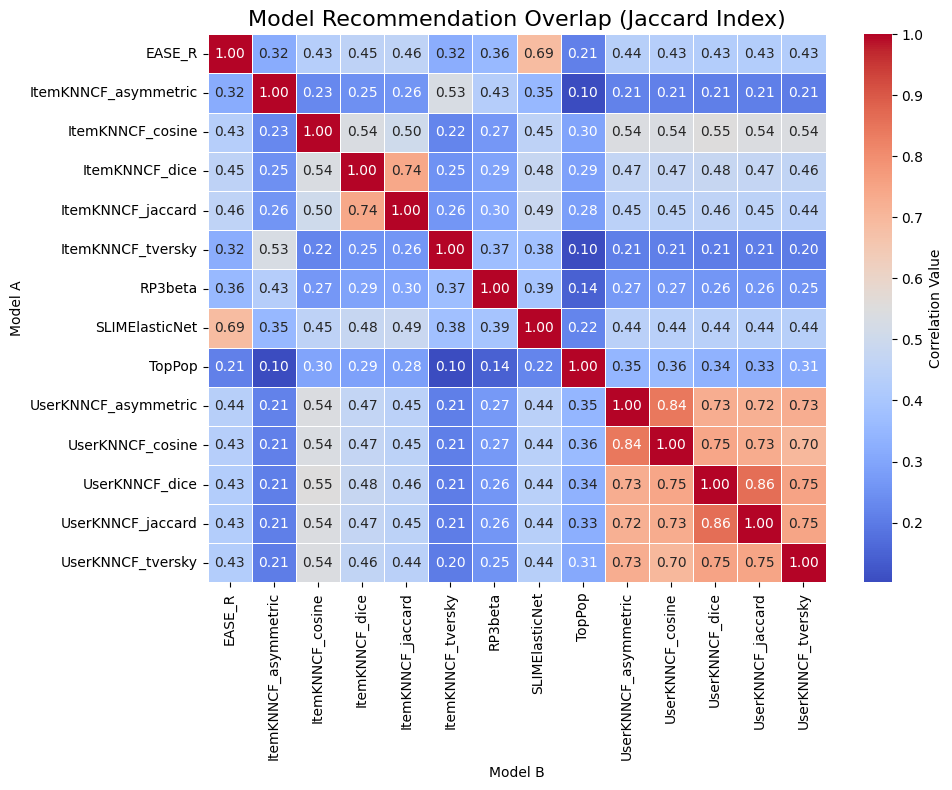

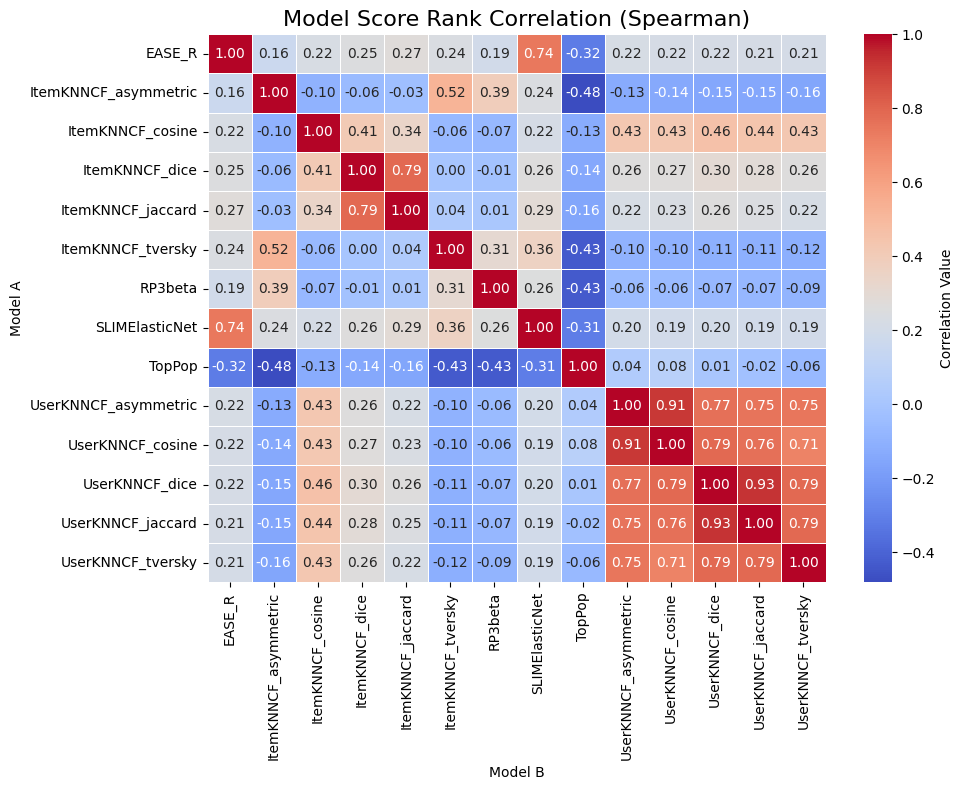

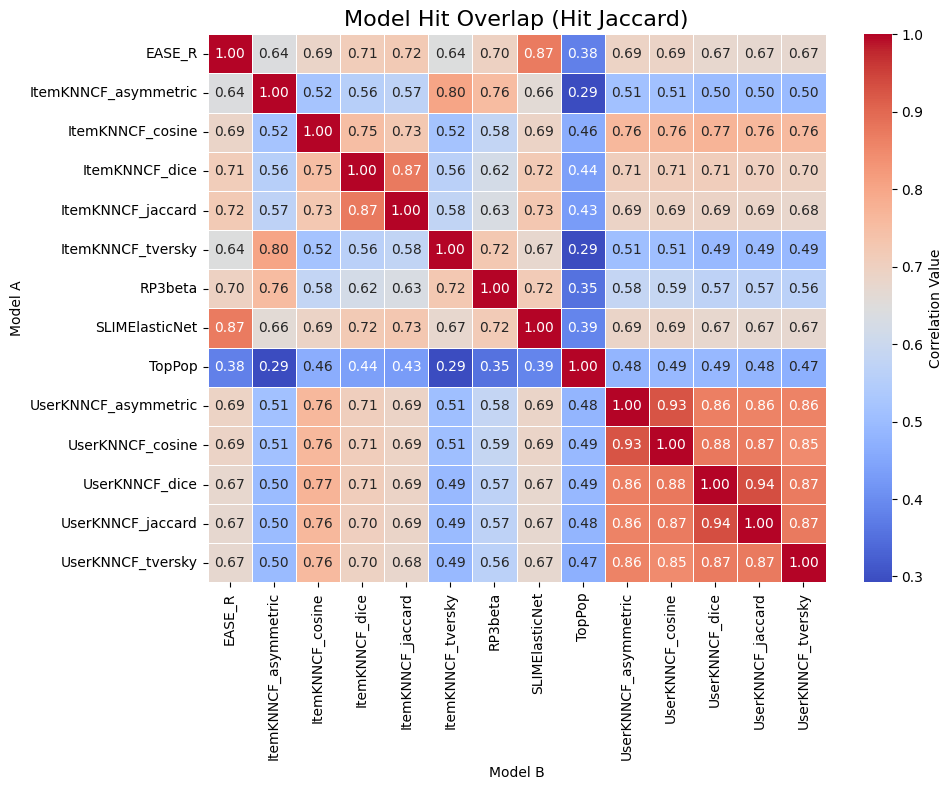

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_heatmap(corr_matrix, title, filename):
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix, 
        annot=True,        # Show the correlation values on the map
        cmap='coolwarm',   # Use a diverging color map (e.g., coolwarm or vlag)
        fmt=".2f",         # Format to 2 decimal places
        linewidths=.5,     # Add lines between cells
        cbar_kws={'label': 'Correlation Value'}
    )
    plt.title(title, fontsize=16)
    plt.ylabel('Model A')
    plt.xlabel('Model B')
    plt.tight_layout()
    plt.show()
    # plt.savefig(filename)
    # plt.close()


plot_correlation_heatmap(jaccard_corr_matrix, 
                         'Model Recommendation Overlap (Jaccard Index)', 
                         'jaccard_heatmap.png')

plot_correlation_heatmap(spearman_corr_matrix, 
                         'Model Score Rank Correlation (Spearman)', 
                         'spearman_heatmap.png')

plot_correlation_heatmap(hit_jaccard_corr_matrix, 
                         'Model Hit Overlap (Hit Jaccard)', 
                         'hit_jaccard_heatmap.png')

In [46]:
evaluator = EvaluatorHoldout(URM_val, [100])

for model_name, model in models.items():
    print(f"Evaluating {model_name}...")
    score = evaluator.evaluateRecommender(model)[0].loc[100, 'RECALL']
    print(f"  Score: {score}")

EvaluatorHoldout: Ignoring 25 ( 0.1%) Users that have less than 1 test interactions
Evaluating TopPop...
EvaluatorHoldout: Processed 27070 (100.0%) in 5.74 sec. Users per second: 4717
  Score: 0.2843590739788499
Evaluating UserKNNCF_cosine...
EvaluatorHoldout: Processed 27070 (100.0%) in 10.00 sec. Users per second: 2707
  Score: 0.4969327085083005
Evaluating ItemKNNCF_cosine...
EvaluatorHoldout: Processed 27070 (100.0%) in 8.06 sec. Users per second: 3358
  Score: 0.49067936147617086
Evaluating UserKNNCF_jaccard...
EvaluatorHoldout: Processed 27070 (100.0%) in 9.44 sec. Users per second: 2867
  Score: 0.4893649315528265
Evaluating ItemKNNCF_jaccard...
EvaluatorHoldout: Processed 27070 (100.0%) in 6.24 sec. Users per second: 4338
  Score: 0.4981355349195207
Evaluating UserKNNCF_asymmetric...
EvaluatorHoldout: Processed 27070 (100.0%) in 9.73 sec. Users per second: 2784
  Score: 0.500011827204119
Evaluating ItemKNNCF_asymmetric...
EvaluatorHoldout: Processed 27070 (100.0%) in 6.71 sec. 

In [48]:
def compute_combination_recall(model_list, URM_val_row, model_sparse_score_matrices):
    """
    Computes the Recall@K=100 for the union of recommendations from models in model_list 
    for a single user.
    """
    # 1. Get the ground truth items for the user
    truth_items = set(URM_val_row.indices)
    
    if len(truth_items) == 0:
        return 0.0
        
    # 2. Collect recommended item IDs from all models in the list
    combined_recs = set()
    for model_name in model_list:
        sparse_row = model_sparse_score_matrices[model_name].getrow(user_ids[user_id])
        combined_recs.update(sparse_row.indices)
        
    # 3. Compute intersection (hits)
    hits = combined_recs.intersection(truth_items)
    
    # Recall = Hits / Total Truth
    return len(hits) / len(truth_items)

# --- Compute Pairwise Recall ---

model_names = list(model_sparse_score_matrices.keys())
n_users = len(user_ids)

# Initialize matrix for pair results
pairwise_recall = pd.DataFrame(1.0, index=model_names, columns=model_names)

print("\nComputing Combined Pairwise Recall...")

for name_A in model_names:
    for name_B in model_names:
        if name_A == name_B:
            # Use the single model's score
            # Find the score in your evaluation list (manual lookup or dictionary)
            # Example: 0.58293153 for SLIM
            pass # We will fill this in after the loop
        
        elif name_A not in pairwise_recall.index or pairwise_recall.loc[name_A, name_B] < 1.0:
            # Only compute for one half (A, B) and skip if already computed (B, A)
            
            # Aggregate recall across all users for the combination (A U B)
            user_recalls = []
            
            for user_id in range(n_users):
                URM_val_row = URM_val.getrow(user_id)
                
                # Get the union of recommended item IDs
                recs_A = set(model_sparse_score_matrices[name_A].getrow(user_id).indices)
                recs_B = set(model_sparse_score_matrices[name_B].getrow(user_id).indices)
                
                combined_recs = recs_A.union(recs_B)
                truth_items = set(URM_val_row.indices)
                
                if len(truth_items) > 0:
                    hits = combined_recs.intersection(truth_items)
                    user_recalls.append(len(hits) / len(truth_items))
                
            mean_recall = np.mean(user_recalls)
            pairwise_recall.loc[name_A, name_B] = mean_recall
            pairwise_recall.loc[name_B, name_A] = mean_recall

# --- Fill in Diagonal (Single Model Recall) ---
# Use the scores provided in your list (K=100)
single_scores = {
    'TopPop': 0.284359, 'UserKNNCF_cosine': 0.496933, 'ItemKNNCF_cosine': 0.490679, 
    'UserKNNCF_jaccard': 0.489365, 'ItemKNNCF_jaccard': 0.498136, 
    'UserKNNCF_asymmetric': 0.500012, 'ItemKNNCF_asymmetric': 0.445666, 
    'UserKNNCF_tversky': 0.491951, 'ItemKNNCF_tversky': 0.446042, 
    'UserKNNCF_dice': 0.490030, 'ItemKNNCF_dice': 0.494646, 
    'RP3beta': 0.479054, 'EASE_R': 0.567453, 'SLIMElasticNet': 0.582932
}

for name in model_names:
    if name in single_scores:
        pairwise_recall.loc[name, name] = single_scores[name]
    else:
        # Fallback for models not in the provided score list
        pass 

# Visualize the Pairwise Recall Matrix
print("\n--- Combined Pairwise Recall Matrix (K=100) ---")
print(pairwise_recall.round(4))
# You can plot this as a heatmap similar to the correlation matrices

# --- Compute Top 3 Combinations ---

# Top 3 combinations (triplets)
best_triplets = {}
for triplet in tqdm.auto.tqdm(combinations(model_names, 3)):
    model_list = list(triplet)
    
    # Compute recall for the triplet union across all users
    user_recalls = []
    for user_id in range(n_users):
        URM_val_row = URM_val.getrow(user_id)
        
        combined_recs = set()
        for name in model_list:
            sparse_row = model_sparse_score_matrices[name].getrow(user_id)
            combined_recs.update(sparse_row.indices)
            
        truth_items = set(URM_val_row.indices)
        
        if len(truth_items) > 0:
            hits = combined_recs.intersection(truth_items)
            user_recalls.append(len(hits) / len(truth_items))
            
    best_triplets[triplet] = np.mean(user_recalls)

# Find the best triplet
best_triplet = max(best_triplets, key=best_triplets.get)
best_triplet_recall = best_triplets[best_triplet]

print(f"\nBest 3-Model Combination for Coverage: {best_triplet}")
print(f"Combined Recall @ 100: {best_triplet_recall:.4f}")


Computing Combined Pairwise Recall...

--- Combined Pairwise Recall Matrix (K=100) ---
                      TopPop  UserKNNCF_cosine  ItemKNNCF_cosine  \
TopPop                0.2844            1.0000            1.0000   
UserKNNCF_cosine      1.0000            0.4969            1.0000   
ItemKNNCF_cosine      1.0000            1.0000            0.4907   
UserKNNCF_jaccard     1.0000            1.0000            1.0000   
ItemKNNCF_jaccard     1.0000            1.0000            1.0000   
UserKNNCF_asymmetric  1.0000            1.0000            1.0000   
ItemKNNCF_asymmetric  1.0000            1.0000            1.0000   
UserKNNCF_tversky     1.0000            1.0000            1.0000   
ItemKNNCF_tversky     1.0000            1.0000            1.0000   
UserKNNCF_dice        1.0000            1.0000            1.0000   
ItemKNNCF_dice        1.0000            1.0000            1.0000   
RP3beta               1.0000            1.0000            1.0000   
EASE_R                1.0000

0it [00:00, ?it/s]


Best 3-Model Combination for Coverage: ('UserKNNCF_tversky', 'ItemKNNCF_tversky', 'EASE_R')
Combined Recall @ 100: 0.6655


In [51]:
# print in increasing order
best_triplets_sorted = dict(sorted(best_triplets.items(), key=lambda item: item[1], reverse=True))
best_triplets_sorted

{('UserKNNCF_tversky',
  'ItemKNNCF_tversky',
  'EASE_R'): np.float64(0.6655322678580293),
 ('ItemKNNCF_asymmetric',
  'UserKNNCF_tversky',
  'EASE_R'): np.float64(0.6651632406262615),
 ('UserKNNCF_jaccard',
  'ItemKNNCF_tversky',
  'EASE_R'): np.float64(0.6650606724873147),
 ('ItemKNNCF_tversky',
  'UserKNNCF_dice',
  'EASE_R'): np.float64(0.6650068767719053),
 ('ItemKNNCF_asymmetric',
  'UserKNNCF_dice',
  'EASE_R'): np.float64(0.664748274973072),
 ('UserKNNCF_jaccard',
  'ItemKNNCF_asymmetric',
  'EASE_R'): np.float64(0.6646814328071062),
 ('ItemKNNCF_asymmetric',
  'UserKNNCF_tversky',
  'SLIMElasticNet'): np.float64(0.6645180124360515),
 ('UserKNNCF_asymmetric',
  'ItemKNNCF_tversky',
  'EASE_R'): np.float64(0.6643495327597869),
 ('UserKNNCF_asymmetric',
  'ItemKNNCF_asymmetric',
  'SLIMElasticNet'): np.float64(0.6638825826763483),
 ('UserKNNCF_asymmetric',
  'ItemKNNCF_asymmetric',
  'EASE_R'): np.float64(0.6638085872517209),
 ('UserKNNCF_cosine',
  'ItemKNNCF_tversky',
  'EASE_R

In [57]:
# Calculate the coverage if we add toppop model to the triplets
selection_models = ['ItemKNNCF_asymmetric', 'UserKNNCF_tversky', 'SLIMElasticNet', 'TopPop']
sum_tot_recommended = 0

combination = tuple(selection_models)
user_recalls = []
for user_id in range(n_users):
    URM_val_row = URM_val.getrow(user_id)
    
    combined_recs = set()
    for name in selection_models:
        sparse_row = model_sparse_score_matrices[name].getrow(user_id)
        combined_recs.update(sparse_row.indices)

    sum_tot_recommended += len(combined_recs)
        
    truth_items = set(URM_val_row.indices)
    
    if len(truth_items) > 0:
        hits = combined_recs.intersection(truth_items)
        user_recalls.append(len(hits) / len(truth_items))

combined_recall = np.mean(user_recalls)
print(f"Combined Recall @ 100 with TopPop added: {combined_recall:.4f}")

average_items_per_user = sum_tot_recommended / n_users
print(f"Average unique items recommended per user: {average_items_per_user:.2f}")

Combined Recall @ 100 with TopPop added: 0.6818
Average unique items recommended per user: 232.39


## **Selection Phase**
('ItemKNNCF_asymmetric',
  'UserKNNCF_tversky',
  'SLIMElasticNet'): np.float64(0.6645180124360515)

In [14]:
selection_models = ['ItemKNNCF_asymmetric', 'UserKNNCF_tversky', 'SLIMElasticNet', 'TopPop']

In [15]:
cutoff = 100
n_users, n_items = URM_train.shape

training_dataframe = pd.DataFrame(index=range(0, n_users), columns = ["ItemID"])
training_dataframe.index.name='UserID'

for user_id in tqdm.notebook.tqdm(range(n_users)):    
    recommendations = None
    for model_name in selection_models:
        recommender = models[model_name]
        recommendations_model = recommender.recommend(user_id, cutoff = cutoff)

        if recommendations is None:
            recommendations = recommendations_model
        else:
            recommendations = np.union1d(recommendations, recommendations_model)

    if user_id == 0:
        print(recommendations)
    
    training_dataframe.loc[user_id, "ItemID"] = recommendations
    
training_dataframe = training_dataframe.explode("ItemID")
training_dataframe

  0%|          | 0/27095 [00:00<?, ?it/s]

[  13   86   91  200  203  227  262  275  282  283  291  333  355  372
  457  479  500  531  536  596  625  640  665  729  773  775  808  814
  828  868  886  891  909  955 1009 1013 1038 1043 1106 1131 1146 1183
 1252 1257 1294 1418 1445 1458 1489 1503 1528 1539 1554 1560 1585 1602
 1632 1656 1687 1700 1703 1739 1779 1930 1940 1968 1983 2003 2026 2040
 2052 2061 2080 2093 2101 2108 2110 2115 2150 2162 2168 2223 2228 2232
 2233 2252 2258 2295 2329 2369 2392 2399 2444 2455 2499 2530 2539 2555
 2574 2628 2653 2709 2779 2824 2835 2842 2863 2917 2936 2986 3019 3049
 3135 3236 3239 3256 3300 3316 3373 3408 3410 3436 3441 3496 3512 3514
 3526 3551 3590 3602 3604 3607 3636 3666 3754 3795 3824 3942 3966 3989
 4023 4045 4083 4170 4180 4200 4220 4264 4270 4272 4293 4312 4317 4342
 4349 4351 4373 4381 4486 4533 4534 4545 4570 4709 4720 4813 4835 4877
 4912 4925 5010 5022 5027 5064 5065 5069 5076 5108 5141 5166 5167 5252
 5258 5323 5326 5329 5340 5362 5369 5407 5442 5445 5460 5466 5469 5474
 5489 

,ItemID
UserID,
0,13
0,86
0,91
0,200
0,203
...,...
27094,6685
27094,6691
27094,6724


In [16]:
URM_validation_coo = sps.coo_matrix(URM_val)

correct_recommendations = pd.DataFrame({"UserID": URM_validation_coo.row,
                                        "ItemID": URM_validation_coo.col})
correct_recommendations

,UserID,ItemID
0,0,227
1,0,640
2,0,1367
3,0,1417
4,0,1968
...,...,...
608607,27094,6310
608608,27094,6419
608609,27094,6516
608610,27094,6691


In [17]:
training_dataframe = pd.merge(training_dataframe, correct_recommendations, on=['UserID','ItemID'], how='left', indicator='Exist')
training_dataframe["Label"] = training_dataframe["Exist"] == "both"
training_dataframe.drop(columns = ['Exist'], inplace=True)
training_dataframe

,UserID,ItemID,Label
0,0,13,False
1,0,86,False
2,0,91,False
3,0,200,False
4,0,203,False
...,...,...,...
6296645,27094,6685,False
6296646,27094,6691,True
6296647,27094,6724,False
6296648,27094,6729,False


In [18]:
training_dataframe.Label.sum()

np.int64(373385)

In [19]:
training_dataframe.reset_index()

,index,UserID,ItemID,Label
0,0,0,13,False
1,1,0,86,False
2,2,0,91,False
3,3,0,200,False
4,4,0,203,False
...,...,...,...,...
6296645,6296645,27094,6685,False
6296646,6296646,27094,6691,True
6296647,6296647,27094,6724,False
6296648,6296648,27094,6729,False


In [20]:
import gc

def get_user_batches(user_ids, batch_size=1000):
    for i in range(0, len(user_ids), batch_size):
        yield user_ids[i:i + batch_size]

# Extract unique (UserID, ItemID) candidates
feature_candidates = training_dataframe[['UserID', 'ItemID']].copy()
N_CANDIDATES = len(feature_candidates)
new_features_to_merge = [] 
unique_users = feature_candidates['UserID'].unique()
BATCH_SIZE = 1000 # Define your batch size here

# --- 2. Refactored Feature Extraction Loop (Model by Model) ---
for label, recommender in models.items():
    print(f"Processing features for model: {label}")
    
    # Pre-allocate arrays for the new features (only size of the candidate set)
    current_scores = np.zeros(N_CANDIDATES, dtype=np.float32)
    current_ranks = np.zeros(N_CANDIDATES, dtype=np.int32)
    
    # Iterate over user batches
    for user_batch in tqdm.tqdm(list(get_user_batches(unique_users, BATCH_SIZE)), desc=f"Processing Batches for {label}", leave=False):
        
        scores_batch = recommender._compute_item_score(user_id_array=user_batch)

        # Normalize
        norm_factor = np.linalg.norm(scores_batch, np.inf, axis=1, keepdims=True) + 1e-6
        linf_scores_batch = scores_batch / norm_factor

        # Remove 
        for i, user_id in enumerate(user_batch):
            linf_scores_batch[i, :] = recommender._remove_seen_on_scores(user_id, linf_scores_batch[i, :])

        # Calculate rank
        rank_order = np.argsort(linf_scores_batch, axis=1)[:, ::-1]
        rank_matrix_batch = np.zeros_like(linf_scores_batch, dtype=np.int32)

        for i in range(len(user_batch)):
            rank_matrix_batch[i, rank_order[i, :]] = np.arange(len(scores_batch[i]))

        # Create a mapping from UserID to its index within the current batch (0 to N_batch-1)
        user_to_batch_index = {uid: i for i, uid in enumerate(user_batch)}
        
        # Get all candidates rows belonging to the current batch of users
        batch_mask = feature_candidates['UserID'].isin(user_batch)
        batch_candidate_indices = feature_candidates.index[batch_mask].to_numpy()
        
        # Identify ItemIDs and map UserIDs to the batch index
        candidate_item_ids = feature_candidates.loc[batch_candidate_indices, 'ItemID'].to_numpy().astype(np.int32)
        candidate_user_ids = feature_candidates.loc[batch_candidate_indices, 'UserID'].to_numpy()
        
        # Map the UserIDs to their row index in the N_batch dimension (0, 1, 2, ...)
        batch_row_indices = np.array([user_to_batch_index[uid] for uid in candidate_user_ids])
        
        # Perform the final indexed lookup (2D indexing on the batch matrices)
        current_scores[batch_candidate_indices] = linf_scores_batch[batch_row_indices, candidate_item_ids]
        current_ranks[batch_candidate_indices] = rank_matrix_batch[batch_row_indices, candidate_item_ids]
        
        # CRITICAL: Delete the temporary large matrices
        del scores_batch, linf_scores_batch, rank_matrix_batch, rank_order
        gc.collect()

    # Finalize and store the new features
    df_features = pd.DataFrame({
        f"{label}_Score": current_scores,
        f"{label}_RankPosition": current_ranks,
        f"{label}_Recommended": (current_ranks < 10).astype(int)
    })
    new_features_to_merge.append(df_features)
    
    # Cleanup for the next model
    del current_scores, current_ranks, df_features
    gc.collect()

# Concatenate all new feature DataFrames along the columns axis
all_new_features = pd.concat(new_features_to_merge, axis=1)

# Add the new feature columns back to the main DataFrame
for col in all_new_features.columns:
    training_dataframe[col] = all_new_features[col].values
    
training_dataframe = training_dataframe.set_index('UserID') 

# Final cleanup
del all_new_features, feature_candidates
gc.collect()

Processing features for model: TopPop


Processing features for model: UserKNNCF_cosine


Processing features for model: ItemKNNCF_cosine


Processing features for model: UserKNNCF_jaccard


Processing features for model: ItemKNNCF_jaccard


Processing features for model: UserKNNCF_asymmetric


Processing features for model: ItemKNNCF_asymmetric


Processing features for model: UserKNNCF_tversky


Processing features for model: ItemKNNCF_tversky


Processing features for model: UserKNNCF_dice


Processing features for model: ItemKNNCF_dice


Processing features for model: RP3beta


Processing features for model: EASE_R


Processing features for model: SLIMElasticNet


0

In [21]:
training_dataframe

,ItemID,Label,TopPop_Score,TopPop_RankPosition,TopPop_Recommended,UserKNNCF_cosine_Score,UserKNNCF_cosine_RankPosition,UserKNNCF_cosine_Recommended,ItemKNNCF_cosine_Score,ItemKNNCF_cosine_RankPosition,...,ItemKNNCF_dice_Recommended,RP3beta_Score,RP3beta_RankPosition,RP3beta_Recommended,EASE_R_Score,EASE_R_RankPosition,EASE_R_Recommended,SLIMElasticNet_Score,SLIMElasticNet_RankPosition,SLIMElasticNet_Recommended
UserID,,,,,,,,,,,,,,,,,,,,,
0,13,False,0.042611,1293,0,0.014977,1625,0,0.209837,546,...,0,0.053748,285,0,0.118035,150,0,0.163806,76,0
0,86,False,0.316351,78,0,0.215350,59,0,0.452824,95,...,0,0.091803,123,0,0.206470,47,0,0.158989,80,0
0,91,False,0.282824,99,0,0.065077,416,0,0.509713,57,...,0,0.052190,299,0,0.108207,183,0,0.069853,257,0
0,200,False,0.345477,59,0,0.052463,526,0,0.175483,688,...,0,0.000000,2440,0,0.033840,864,0,0.018671,809,0
0,203,False,0.097865,588,0,0.040785,693,0,0.229241,483,...,0,0.046765,371,0,0.107511,184,0,0.027149,624,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27094,6685,False,0.054879,990,0,0.267268,92,0,0.423669,102,...,0,0.158565,89,0,0.180856,193,0,0.102927,303,0
27094,6691,True,0.016482,2276,0,0.119700,417,0,0.289196,244,...,0,0.177502,65,0,0.180393,194,0,0.263165,84,0
27094,6724,False,0.021071,2002,0,0.211688,166,0,0.322881,194,...,0,0.049449,736,0,0.218773,138,0,0.147137,199,0


In [ ]:
from scipy import stats

def calculate_item_item_features_batched(training_dataframe, URM_train, models, batch_size=1000):
    stats_list = ['Avg', 'Max', 'Min', 'Std', 'Skew', 'Kurtosis']
    all_user_ids = training_dataframe.index.unique().to_numpy()
    
    # Store initial features to merge at the end
    df_features_to_merge = training_dataframe.reset_index()[['UserID', 'ItemID']].copy()
    N_CANDIDATES = len(df_features_to_merge)

    for similarity_type, recommender in [
            ('ItemKNN_cosine', models['ItemKNNCF_cosine']), 
            ('ItemKNN_tversky', models['ItemKNNCF_tversky']),
            ('RP3beta', models['RP3beta'])
        ]:
        print(f"Adding {similarity_type} similarity features (Batched & Sparse Optimized)...")
        
        # Use the SPARSE Similarity Matrix
        W_sparse = recommender.W_sparse.tocsr() 
        
        # Prepare storage for the new feature columns (size: N_candidates)
        new_features = {
            f"{stat}SimilarityToSeen{similarity_type}": np.zeros(N_CANDIDATES, dtype=np.float32) 
            for stat in stats_list
        }
        
        # Loop over user batches
        user_batches = list(get_user_batches(all_user_ids, batch_size))
        for user_batch in tqdm.tqdm(user_batches, desc=f"Processing Batches for {similarity_type}"):
            # Identify all candidates belonging to the current batch of users
            batch_mask = df_features_to_merge['UserID'].isin(user_batch)
            
            # Initialize storage for the stats arrays for this batch
            batch_stats_results = {stat: [] for stat in stats_list}
            
            for user_id in user_batch:
                # Get the candidate indices within the *full* df_features_to_merge for this *single* user
                user_candidate_indices = df_features_to_merge.index[
                    (df_features_to_merge['UserID'] == user_id) & batch_mask
                ].to_numpy()
                
                if len(user_candidate_indices) == 0:
                    continue # No candidates for this user in the training set
                
                # Items the user has interacted with
                seen_items = URM_train.getrow(user_id).nonzero()[1]
                
                # Get candidate item IDs for this user only
                current_candidate_item_ids = df_features_to_merge.loc[user_candidate_indices, 'ItemID'].values.astype(np.int32)
                
                if len(seen_items) == 0:
                    # Append zeros for all candidates of this user
                    num_candidates = len(user_candidate_indices)
                    for stat in stats_list:
                         batch_stats_results[stat].append(np.zeros(num_candidates, dtype=np.float32))
                    continue
                    
                # Extract Similarity Scores using SPARSE Slicing (Vectorized across N_candidates)
                similarities_candidate_rows = W_sparse[current_candidate_item_ids, :] 
                similarities_slice = similarities_candidate_rows[:, seen_items]
                similarities = similarities_slice.toarray()
                
                # Calculate statistics
                results = {
                    "Avg": similarities.mean(axis=1),
                    "Max": similarities.max(axis=1),
                    "Min": similarities.min(axis=1),
                    "Std": similarities.std(axis=1),
                    "Skew": stats.skew(similarities, axis=1),
                    "Kurtosis": stats.kurtosis(similarities, axis=1)
                }
                
                # Store results for later assignment
                for stat, value in results.items():
                    batch_stats_results[stat].append(value)

                del similarities, similarities_slice, similarities_candidate_rows
                gc.collect()

            #  Concatenate and assign the results for the whole batch
            if batch_stats_results['Avg']: # Check if any results were actually collected
                for stat in stats_list:
                    # Concatenate all user results for this stat into one array
                    stat_values = np.concatenate(batch_stats_results[stat])
                    
                    # Find the specific indices within the main feature array where these values go
                    batch_candidates_sorted = df_features_to_merge[batch_mask].index.to_numpy()
                    
                    # The gathered stat_values must correspond exactly to the order of batch_candidates_sorted
                    new_features[f"{stat}SimilarityToSeen{similarity_type}"][batch_candidates_sorted] = stat_values

        # Add the completed feature columns to the merge DataFrame
        for col_name, data in new_features.items():
            df_features_to_merge[col_name] = data

    # --- 5. Final Merge (Same as before) ---
    training_dataframe = pd.merge(training_dataframe.reset_index(), 
                                 df_features_to_merge, 
                                 on=['UserID', 'ItemID'], 
                                 how='left',
                                 suffixes=('_old', ''))

    training_dataframe = training_dataframe.set_index('UserID')
    
    del df_features_to_merge, W_sparse
    gc.collect()
    
    return training_dataframe

In [23]:
training_dataframe = calculate_item_item_features_batched(training_dataframe, URM_train, models)

Adding ItemKNN_cosine similarity features (Batched & Sparse Optimized)...


Processing Batches for ItemKNN_cosine: 100%|██████████| 28/28 [25:16<00:00, 54.16s/it]


Adding ItemKNN_tversky similarity features (Batched & Sparse Optimized)...


Processing Batches for ItemKNN_tversky: 100%|██████████| 28/28 [25:01<00:00, 53.61s/it]


Adding RP3beta similarity features (Batched & Sparse Optimized)...


Processing Batches for RP3beta: 100%|██████████| 28/28 [25:02<00:00, 53.66s/it]


In [25]:
# Final Meta-Features

# A. Consensus Features (Fast)
recommended_columns = [col for col in training_dataframe.columns if col.endswith('_Recommended')]
training_dataframe['Counter_Recommended'] = training_dataframe[recommended_columns].sum(axis=1).astype(int)

# B. Rank Position Statistics (Fast)
position_columns = [col for col in training_dataframe.columns if col.endswith('_RankPosition')]

training_dataframe['Mean_RankPosition'] = training_dataframe[position_columns].mean(axis=1)
training_dataframe['Std_RankPosition'] = training_dataframe[position_columns].std(axis=1)
training_dataframe['Skew_RankPosition'] = training_dataframe[position_columns].skew(axis=1)
training_dataframe['Kurtosis_RankPosition'] = training_dataframe[position_columns].kurtosis(axis=1)

# C. Score Statistics (CRITICAL ADDITION)
score_columns = [col for col in training_dataframe.columns if col.endswith('_Score')]

training_dataframe['Mean_Score'] = training_dataframe[score_columns].mean(axis=1)
training_dataframe['Std_Score'] = training_dataframe[score_columns].std(axis=1)
training_dataframe['Skew_Score'] = training_dataframe[score_columns].skew(axis=1)
training_dataframe['Kurtosis_Score'] = training_dataframe[score_columns].kurtosis(axis=1)


# D. Final Cleanup and Index Reset
# We ensure the index is a regular column and any intermediate index is removed.
# Assuming 'UserID' is the name of the index at this point from previous steps
if training_dataframe.index.name == 'UserID':
    training_dataframe = training_dataframe.reset_index()
else:
    # If index is unnamed (from a previous reset), just reset it and ensure columns are unique
    training_dataframe = training_dataframe.reset_index(drop=True)

print("Feature Engineering Complete. 🎉")
print(f"Final DataFrame shape: {training_dataframe.shape}")

Feature Engineering Complete. 🎉
Final DataFrame shape: (6296650, 72)


In [26]:
# Example check
assert 'UserID' in training_dataframe.columns
assert 'ItemID' in training_dataframe.columns
assert training_dataframe.shape[0] == 6296650

print("\n## ⚠️ Missing Value Check (Should be near zero)")
print(training_dataframe.isnull().sum().sort_values(ascending=False).head(10))

print("\n## 🎯 Rank and Consensus Checks")
# Max rank should be less than the total number of items (N_items)
print(f"Max Rank Position: {training_dataframe['ItemKNNCF_cosine_RankPosition'].max()}") 
# Max consensus count should match the number of models used
print(f"Max Recommended Counter: {training_dataframe['Counter_Recommended'].max()}")

print("\n## 📈 Similarity Feature Range Check")
# Example for Cosine Avg Similarity
print(f"Max Mean Cosine Sim: {training_dataframe['AvgSimilarityToSeenItemKNN_cosine'].max()}")
print(f"Min Mean Cosine Sim: {training_dataframe['AvgSimilarityToSeenItemKNN_cosine'].min()}")

print("\n## 📊 Meta-Feature Statistics (Descriptive)")
print(training_dataframe[['Mean_RankPosition', 'Std_RankPosition', 'Skew_RankPosition']].describe())
print(training_dataframe[['Mean_Score', 'Std_Score']].describe())


## ⚠️ Missing Value Check (Should be near zero)
SkewSimilarityToSeenItemKNN_tversky        3953972
KurtosisSimilarityToSeenItemKNN_tversky    3953972
SkewSimilarityToSeenRP3beta                2970877
KurtosisSimilarityToSeenRP3beta            2970877
KurtosisSimilarityToSeenItemKNN_cosine      347967
SkewSimilarityToSeenItemKNN_cosine          347967
UserID                                           0
ItemID                                           0
UserKNNCF_cosine_RankPosition                    0
UserKNNCF_cosine_Score                           0
dtype: int64

## 🎯 Rank and Consensus Checks
Max Rank Position: 6956
Max Recommended Counter: 14

## 📈 Similarity Feature Range Check
Max Mean Cosine Sim: 0.3838898241519928
Min Mean Cosine Sim: 0.0

## 📊 Meta-Feature Statistics (Descriptive)
       Mean_RankPosition  Std_RankPosition  Skew_RankPosition
count       6.296650e+06      6.296650e+06       6.296650e+06
mean        1.094613e+03      1.201687e+03       1.574386e+00
std         

In [27]:
# Apply the fix immediately after the feature engineering steps
for col in training_dataframe.columns:
    if 'SimilarityToSeen' in col and training_dataframe[col].isnull().any():
        # Impute Skew/Kurtosis NaNs with 0.0
        training_dataframe[col] = training_dataframe[col].fillna(0.0)

print("NaNs in Skew/Kurtosis imputed to 0.0.")

NaNs in Skew/Kurtosis imputed to 0.0.


In [30]:
# Example check
assert 'UserID' in training_dataframe.columns
assert 'ItemID' in training_dataframe.columns
assert training_dataframe.shape[0] == 6296650

print("\n## ⚠️ Missing Value Check (Should be near zero)")
print(training_dataframe.isnull().sum().sort_values(ascending=False).head(10))

print("\n## 🎯 Rank and Consensus Checks")
# Max rank should be less than the total number of items (N_items)
print(f"Max Rank Position: {training_dataframe['ItemKNNCF_cosine_RankPosition'].max()}") 
# Max consensus count should match the number of models used
print(f"Max Recommended Counter: {training_dataframe['Counter_Recommended'].max()}")

print("\n## 📈 Similarity Feature Range Check")
# Example for Cosine Avg Similarity
print(f"Max Mean Cosine Sim: {training_dataframe['AvgSimilarityToSeenItemKNN_cosine'].max()}")
print(f"Min Mean Cosine Sim: {training_dataframe['AvgSimilarityToSeenItemKNN_cosine'].min()}")

print("\n## 📊 Meta-Feature Statistics (Descriptive)")
print(training_dataframe[['Mean_RankPosition', 'Std_RankPosition', 'Skew_RankPosition']].describe())
print(training_dataframe[['Mean_Score', 'Std_Score']].describe())


## ⚠️ Missing Value Check (Should be near zero)
UserID                           0
ItemID                           0
Label                            0
TopPop_Score                     0
TopPop_RankPosition              0
TopPop_Recommended               0
UserKNNCF_cosine_Score           0
UserKNNCF_cosine_RankPosition    0
UserKNNCF_cosine_Recommended     0
ItemKNNCF_cosine_Score           0
dtype: int64

## 🎯 Rank and Consensus Checks
Max Rank Position: 6956
Max Recommended Counter: 14

## 📈 Similarity Feature Range Check
Max Mean Cosine Sim: 0.3838898241519928
Min Mean Cosine Sim: 0.0

## 📊 Meta-Feature Statistics (Descriptive)
       Mean_RankPosition  Std_RankPosition  Skew_RankPosition
count       6.296650e+06      6.296650e+06       6.296650e+06
mean        1.094613e+03      1.201687e+03       1.574386e+00
std         1.220563e+03      9.240420e+02       1.169546e+00
min         0.000000e+00      0.000000e+00      -3.741657e+00
25%         2.379286e+02      2.760505e+02      

In [29]:
training_dataframe.head()

,UserID,ItemID,Label,TopPop_Score,TopPop_RankPosition,TopPop_Recommended,UserKNNCF_cosine_Score,UserKNNCF_cosine_RankPosition,UserKNNCF_cosine_Recommended,ItemKNNCF_cosine_Score,...,KurtosisSimilarityToSeenRP3beta,Counter_Recommended,Mean_RankPosition,Std_RankPosition,Skew_RankPosition,Kurtosis_RankPosition,Mean_Score,Std_Score,Skew_Score,Kurtosis_Score
0,0,13,False,0.042611,1293,0,0.014977,1625,0,0.209837,...,53.387196,0,795.428571,729.105323,0.419123,-1.741309,0.085261,0.068488,0.382717,-1.349591
1,0,86,False,0.316351,78,0,0.215350,59,0,0.452824,...,0.000000,0,312.142857,688.155937,3.620981,13.330073,0.177590,0.106849,1.225503,2.925417
2,0,91,False,0.282824,99,0,0.065077,416,0,0.509713,...,0.000000,0,627.500000,889.389484,2.203348,3.534845,0.120924,0.133128,2.228959,5.527642
3,0,200,False,0.345477,59,0,0.052463,526,0,0.175483,...,0.000000,0,1397.785714,1000.920052,0.486664,-1.364717,0.056891,0.095408,2.543800,6.782011
4,0,203,False,0.097865,588,0,0.040785,693,0,0.229241,...,0.000000,0,994.071429,970.388143,1.508478,0.892793,0.060695,0.060832,1.709546,3.853139


In [32]:
training_dataframe.to_csv("XGboost_dataframe.csv", index=False)

## **Train xg boost**

In [34]:
from xgboost import XGBRanker

# --- 1. Prepare Data and Group Counts ---

# CRITICAL: Sort data by UserID to ensure the groups array aligns perfectly 
# with X_train/y_train. If the groupby operation was performed on a sorted DataFrame, 
# this ensures everything stays aligned. If not, it's safer to sort explicitly.
training_dataframe_sorted = training_dataframe.sort_values(by='UserID').reset_index(drop=True)

# 1. Target and Feature Matrix Definition
y_train = training_dataframe_sorted["Label"]

# Drop the identifiers (UserID, ItemID) and the target (Label), keeping only the features
X_train = training_dataframe_sorted.drop(columns=["Label", "UserID", "ItemID"], errors='ignore') 

# 2. Group Calculation (Your successful code)
# This array holds the count of candidates for each user, in the exact order they appear in X_train.
groups = training_dataframe_sorted.groupby("UserID").size().values

# Verification: Ensure the sum of group counts matches the total data size
assert groups.sum() == X_train.shape[0], "Group sum does not match total data size!"

# --- 2. Initialize and Fit XGBRanker ---

# Hyperparameters (Your baseline configuration)
n_estimators = 50
learning_rate = 1e-1
reg_alpha = 1e-1
reg_lambda = 1e-1
max_depth = 5
grow_policy = "depthwise"
objective = "pairwise" 

XGB_model = XGBRanker(objective='rank:{}'.format(objective),
                      n_estimators = int(n_estimators),
                      random_state = 42, # Fixed seed for reproducibility
                      learning_rate = learning_rate,
                      reg_alpha = reg_alpha,
                      reg_lambda = reg_lambda,
                      max_depth = int(max_depth),
                      max_leaves = 0,
                      grow_policy = grow_policy,
                      verbosity = 1, # Set to 1 to see training progress
                      booster = "gbtree",
                      n_jobs=-1 # Use all cores
                      )

In [35]:
print(f"Starting XGBRanker training with {len(groups)} user groups...")

XGB_model.fit(X_train,
              y_train,
              group=groups,
              verbose=True)

Starting XGBRanker training with 27095 user groups...


,objective,'rank:pairwise'
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [39]:
y_pred_scores = XGB_model.predict(X_train)

# Evaluate training performance
from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(y_train, y_pred_scores)
print(f"Training AUC Score: {auc_score:.4f}")

Training AUC Score: 0.8237


In [38]:
len(y_pred_scores)

6296650

<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

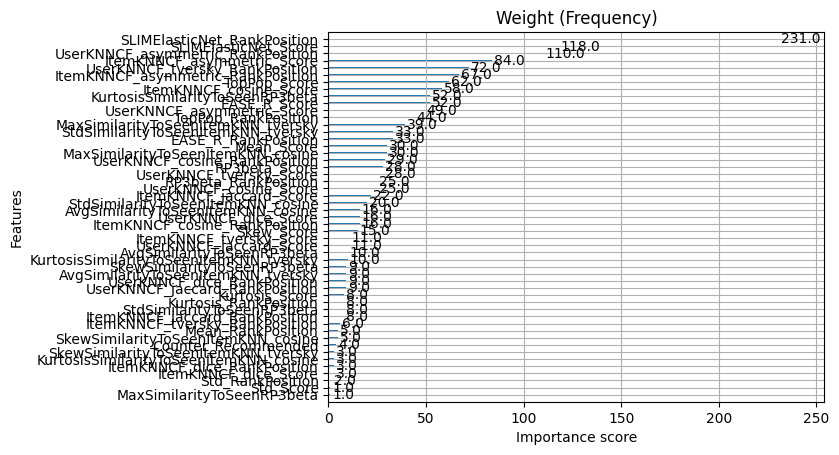

In [40]:
from xgboost import plot_importance
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequency)')

<Axes: title={'center': 'Gain'}, xlabel='Importance score', ylabel='Features'>

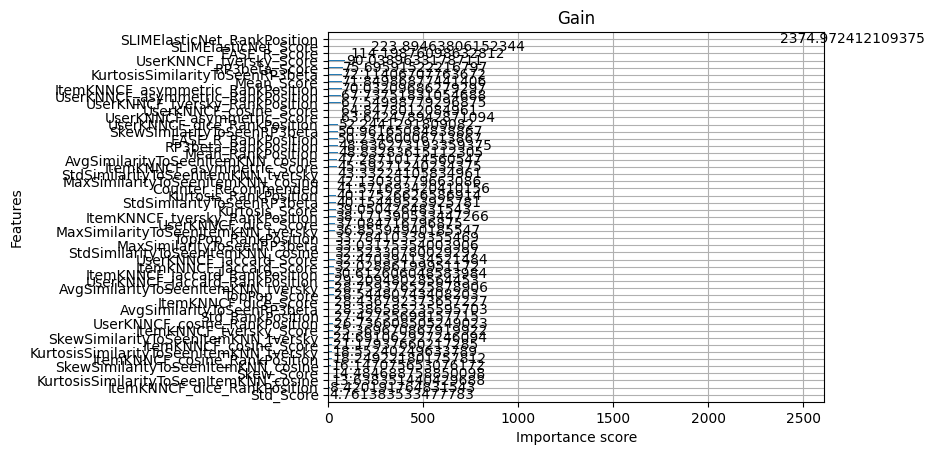

In [42]:
plot_importance(XGB_model, importance_type='gain', title='Gain')

<Axes: title={'center': 'Cover'}, xlabel='Importance score', ylabel='Features'>

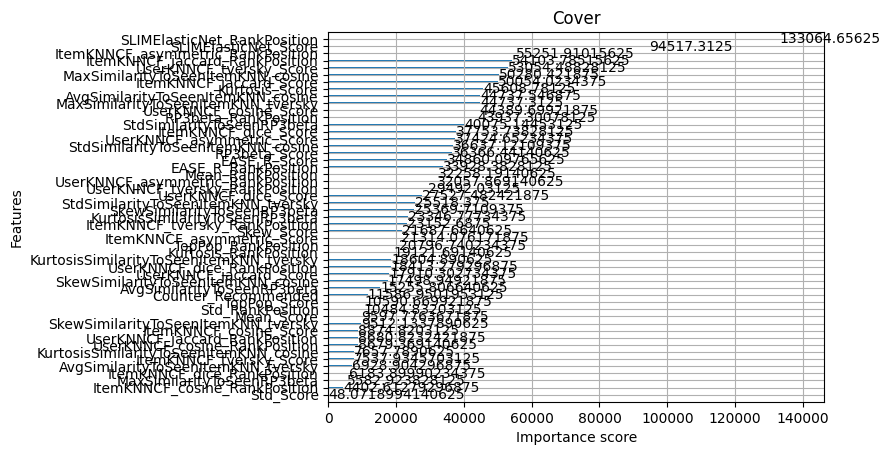

In [43]:
plot_importance(XGB_model, importance_type='cover', title='Cover')

<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

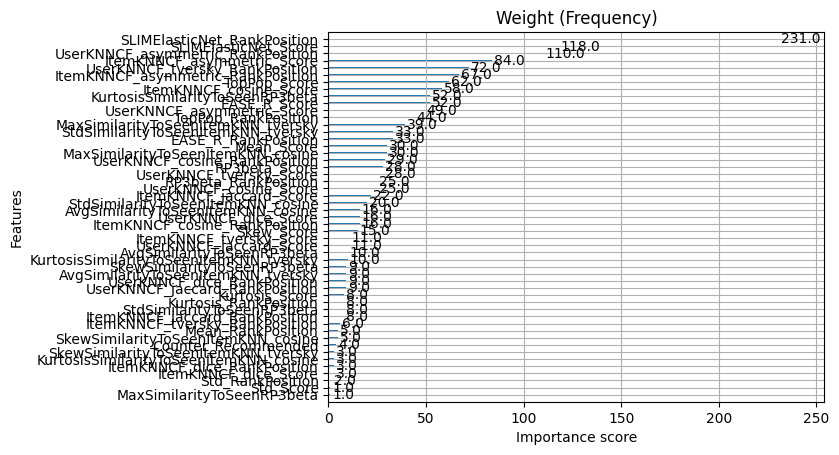

In [46]:
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequency)')

In [47]:
import joblib
import os

# Define a clear file path
MODEL_DIR = "models"
MODEL_FILENAME = "xgb_meta_ranker_v1.joblib"
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_FILENAME)

# Create the directory if it doesn't exist
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

# Save the trained model
joblib.dump(XGB_model, MODEL_PATH)

print(f"✅ XGBRanker model successfully saved to: {MODEL_PATH}")

✅ XGBRanker model successfully saved to: models/xgb_meta_ranker_v1.joblib
